# Cài đặt và Thiết lập đường dẫn

In [1]:
# ==============================================================================
# 1. CÀI ĐẶT THƯ VIỆN & THIẾT LẬP ĐƯỜNG DẪN
# ==============================================================================
!pip install -q -U transformers datasets peft trl bitsandbytes accelerate
!pip install -q -U langchain-core langchain-community langchain-chroma langchain-huggingface
!pip install -q nltk rouge-score bert-score tqdm pandas

import os
import json
import torch
from google.colab import drive
from datasets import Dataset

# Kết nối Drive
drive.mount('/content/drive', force_remount=True)
BASE_PATH = "/content/drive/MyDrive/NLP"
DATASET_DIR = os.path.join(BASE_PATH, "data/datasets")
VECTOR_DB_DIR = os.path.join(BASE_PATH, "vector_db_parent_child")
ADAPTER_PATH = os.path.join(BASE_PATH, "checkpoints/qwen_lora_law_production")
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

# File dữ liệu
PARENT_JSON = os.path.join(DATASET_DIR, "parents_traffic_law.json")
TEST_FILE = os.path.join(DATASET_DIR, "data_qa_test.json")

Mounted at /content/drive


# Tái tạo Parent-Child Knowledge Base

In [2]:
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.runnables import RunnableLambda

print("[*] Đang tái tạo Knowledge Base từ Drive...")

# 1. Nạp Parents vào RAM
with open(PARENT_JSON, "r", encoding="utf-8") as f:
    parents_data = json.load(f)
docstore = InMemoryStore()
docstore.mset([(p["doc_id"], Document(page_content=p["content"], metadata=p["metadata"])) for p in parents_data])

# 2. Kết nối ChromaDB
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
vectorstore = Chroma(
    collection_name="child_chunks_collection",
    embedding_function=embedding_model,
    persist_directory=VECTOR_DB_DIR
)

# 3. Custom Retriever
def retrieve_parent_docs(query: str, k: int = 3):
    child_docs = vectorstore.similarity_search(query, k=k)
    parent_ids = list(set([doc.metadata.get("parent_id") for doc in child_docs if "parent_id" in doc.metadata]))
    docs = docstore.mget(parent_ids)
    return [d for d in docs if d is not None]

parent_retriever = RunnableLambda(lambda query: retrieve_parent_docs(query, k=3))

[*] Đang tái tạo Knowledge Base từ Drive...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

# Nạp Mô hình và Thiết lập RAG Chain Chống Ảo Giác

In [3]:
# ==============================================================================
# 3. TẢI MÔ HÌNH & THIẾT LẬP RAG CHAIN CHỐNG ẢO GIÁC (CHUẨN CHATML)
# ==============================================================================
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from peft import PeftModel
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

print("[*] Đang nạp mô hình Qwen và trọng số Adapter...")

# 1. Load Model & Adapter
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map="auto")
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()

# 2. Pipeline sinh văn bản (Bật Batching và tắt cảnh báo max_length)
model_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=400,
    max_length=None,              # Tắt cảnh báo giới hạn độ dài kép
    temperature=0.01,
    top_p=0.1,
    do_sample=True,
    batch_size=4,                 # Ép GPU xử lý song song 4 câu
    pad_token_id=tokenizer.eos_token_id # Bắt buộc có khi dùng batch
)
hf_llm = HuggingFacePipeline(pipeline=model_pipeline)

# 3. Strict Prompt Template chuẩn ChatML (Ngăn Qwen nói nhảm kịch trần token)
strict_qwen_prompt = """<|im_start|>system
Bạn là chuyên gia Pháp luật Giao thông Việt Nam. CHỈ SỬ DỤNG thông tin từ [TÀI LIỆU CĂN CỨ] để trả lời. Nếu không có thông tin, hãy nói: "Dựa trên tài liệu hiện tại, không có quy định cụ thể về vấn đề này." CẤM tự bịa đặt thông tin ngoài tài liệu.<|im_end|>
<|im_start|>user
[TÀI LIỆU CĂN CỨ]:
{context}

[CÂU HỎI]:
{question}<|im_end|>
<|im_start|>assistant
"""

def format_docs(docs):
    return "\n\n".join([f"--- [Nguồn: {d.metadata.get('article', 'Luật')}] ---\n{d.page_content}" for d in docs])

# 4. Khởi tạo RAG Chain
rag_chain = (
    {"context": parent_retriever | format_docs, "question": RunnablePassthrough()}
    | PromptTemplate.from_template(strict_qwen_prompt)
    | hf_llm
    | StrOutputParser()
)
print("[+] Hoàn tất thiết lập Pipeline và RAG Chain!")

[*] Đang nạp mô hình Qwen và trọng số Adapter...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'top_p', 'max_new_tokens', 'max_length', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[+] Hoàn tất thiết lập Pipeline và RAG Chain!


# Chạy Đánh giá và Xuất Bảng Kết quả

In [10]:
# ==============================================================================
# 4. ĐÁNH GIÁ 4 CẤU HÌNH (ĐỒNG BỘ HÓA NATIVE BATCHING & FIX LỖI FULL TEXT)
# ==============================================================================
import pandas as pd
import torch
import gc
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --- 1. HÀM TẠO SINH THEO LÔ DÙNG CHUNG CHO CẢ NO-RAG VÀ RAG ---
def generate_batch_universal(model, tokenizer, prompts, batch_size=8):
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    stop_token_ids = [tokenizer.eos_token_id]
    if "<|im_end|>" in tokenizer.get_vocab():
        stop_token_ids.append(tokenizer.get_vocab()["<|im_end|>"])

    all_answers = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="Đang sinh văn bản (GPU)"):
        batch_prompts = prompts[i:i+batch_size]
        tokenizer.padding_side = "left"

        # Giới hạn max_length để an toàn bộ nhớ khi nạp RAG context
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=300,
                temperature=0.01,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=stop_token_ids
            )

        # CẮT BỎ PHẦN PROMPT, CHỈ LẤY CÂU TRẢ LỜI CỦA MODEL
        for j, out in enumerate(outputs):
            input_len = inputs.input_ids[j].shape[0]
            ans = tokenizer.decode(out[input_len:], skip_special_tokens=True)
            ans = ans.replace("<|im_end|>", "").strip()
            all_answers.append(ans)

    return all_answers

# --- 2. HÀM CHẤM ĐIỂM ---
smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def eval_metrics(preds, refs):
    bleu_scores = [sentence_bleu([nltk.word_tokenize(r)], nltk.word_tokenize(p), smoothing_function=smoother) for p, r in zip(preds, refs)]
    rouge_scores = [rouge.score(r, p)['rougeL'].fmeasure for p, r in zip(preds, refs)]
    P, R, F1 = bert_score(preds, refs, lang="vi", verbose=False)
    return sum(bleu_scores)/len(bleu_scores), sum(rouge_scores)/len(rouge_scores), F1.mean().item()

# --- 3. TIỀN XỬ LÝ DỮ LIỆU VÀ PROMPT ---
with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)

references = [item['answer'] for item in test_data]
queries = [item['question'] for item in test_data]

# 3.1. Chuẩn bị Prompt cho Cấu hình A & C (No RAG)
no_rag_prompts = [
    f"<|im_start|>system\nBạn là chuyên gia Pháp luật Giao thông Việt Nam.<|im_end|>\n<|im_start|>user\nCâu hỏi: {q}<|im_end|>\n<|im_start|>assistant\n"
    for q in queries
]

# 3.2. Chuẩn bị Prompt cho Cấu hình B & D (Có RAG)
def format_docs_safe(docs):
    text = "\n\n".join([f"--- [Nguồn: {d.metadata.get('article', 'Luật')}] ---\n{d.page_content}" for d in docs])
    return text[:2000] # Giới hạn 2000 ký tự để an toàn VRAM mà vẫn đủ ý

rag_prompts = []
for q in tqdm(queries, desc="Đang truy xuất tài liệu (CPU)"):
    docs = parent_retriever.invoke(q)
    context = format_docs_safe(docs)
    prompt = f"""<|im_start|>system
Bạn là chuyên gia Pháp luật Giao thông Việt Nam. CHỈ SỬ DỤNG thông tin từ [TÀI LIỆU CĂN CỨ] để trả lời. Nếu không có thông tin, hãy nói: "Dựa trên tài liệu hiện tại, không có quy định cụ thể về vấn đề này." CẤM tự bịa đặt thông tin.<|im_end|>
<|im_start|>user
[TÀI LIỆU CĂN CỨ]:
{context}

[CÂU HỎI]:
{q}<|im_end|>
<|im_start|>assistant\n"""
    rag_prompts.append(prompt)


# --- 4. TIẾN HÀNH CHẠY THỰC NGHIỆM ---
results = []
BATCH_SIZE = 8

print("\n[*] BẮT ĐẦU ĐÁNH GIÁ 4 CẤU HÌNH (NATIVE BATCHING)")

# A. Base (No RAG)
print("\n[1/4] Đánh giá: A. Base Model (No RAG)")
torch.cuda.empty_cache(); gc.collect()
with model.disable_adapter():
    preds_A = generate_batch_universal(model, tokenizer, no_rag_prompts, batch_size=BATCH_SIZE)
results.append(["A. Base Model (No RAG)", *eval_metrics(preds_A, references)])

# B. Base + RAG
print("\n[2/4] Đánh giá: B. Base Model + RAG")
torch.cuda.empty_cache(); gc.collect()
with model.disable_adapter():
    preds_B = generate_batch_universal(model, tokenizer, rag_prompts, batch_size=BATCH_SIZE)
results.append(["B. Base Model + RAG", *eval_metrics(preds_B, references)])

# C. Fine-tuned (No RAG)
print("\n[3/4] Đánh giá: C. Fine-tuned Model (No RAG)")
torch.cuda.empty_cache(); gc.collect()
preds_C = generate_batch_universal(model, tokenizer, no_rag_prompts, batch_size=BATCH_SIZE)
results.append(["C. Fine-tuned (No RAG)", *eval_metrics(preds_C, references)])

# D. Fine-tuned + RAG
print("\n[4/4] Đánh giá: D. Fine-tuned Model + RAG")
torch.cuda.empty_cache(); gc.collect()
preds_D = generate_batch_universal(model, tokenizer, rag_prompts, batch_size=BATCH_SIZE)
results.append(["D. Fine-tuned + RAG", *eval_metrics(preds_D, references)])


# --- 5. XUẤT KẾT QUẢ ---
df = pd.DataFrame(results, columns=["Configuration", "BLEU", "ROUGE-L", "BERTScore"])
print("\n" + "="*65)
print("KẾT QUẢ ĐÁNH GIÁ TỔNG HỢP")
print("="*65)
print(df.to_markdown(index=False))

Đang truy xuất tài liệu (CPU): 100%|██████████| 50/50 [00:01<00:00, 44.49it/s]



[*] BẮT ĐẦU ĐÁNH GIÁ 4 CẤU HÌNH (NATIVE BATCHING)

[1/4] Đánh giá: A. Base Model (No RAG)


Đang sinh văn bản (GPU): 100%|██████████| 7/7 [09:56<00:00, 85.16s/it]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


[4/4] Đánh giá: D. Fine-tuned Model + RAG


Đang sinh văn bản (GPU): 100%|██████████| 7/7 [04:08<00:00, 35.51s/it]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



KẾT QUẢ ĐÁNH GIÁ TỔNG HỢP
| Configuration          |      BLEU |   ROUGE-L |   BERTScore |
|:-----------------------|----------:|----------:|------------:|
| A. Base Model (No RAG) | 0.0131597 |  0.11567  |    0.640696 |
| B. Base Model + RAG    | 0.0616197 |  0.21863  |    0.694405 |
| C. Fine-tuned (No RAG) | 0.127164  |  0.410906 |    0.775561 |
| D. Fine-tuned + RAG    | 0.216516  |  0.471609 |    0.794064 |


In [8]:
# ==============================================================================
# TÍNH TOÁN VÀ IN CHỈ SỐ RECALL@5 CHO HỆ THỐNG RETRIEVER
# ==============================================================================
def calculate_recall_at_5(test_data, vectorstore, docstore, threshold=0.5):
    hits = 0
    for item in tqdm(test_data, desc="Đang tính Recall@5"):
        q, ans = item['question'], item['answer'].lower()

        # 1. Truy xuất Top 5 child chunks và lấy Parent Docs tương ứng
        child_docs = vectorstore.similarity_search(q, k=5)
        parent_ids = list(set([d.metadata.get("parent_id") for d in child_docs if "parent_id" in d.metadata]))
        docs = [d.page_content.lower() for d in docstore.mget(parent_ids) if d]
        combined_docs = " ".join(docs)

        # 2. Đánh giá Hit (Từ khóa của câu trả lời Ground Truth xuất hiện > 50% trong ngữ cảnh)
        gt_words = set(ans.split())
        doc_words = set(combined_docs.split())
        overlap = len(gt_words.intersection(doc_words)) / len(gt_words) if gt_words else 0

        if overlap >= threshold:
            hits += 1

    return hits / len(test_data)

# Thực thi
recall_5 = calculate_recall_at_5(test_data, vectorstore, docstore)
print(f"Recall@5: {recall_5 * 100:.2f}%")

Đang tính Recall@5: 100%|██████████| 50/50 [00:01<00:00, 33.50it/s]

Recall@5: 96.00%


/tmp/ipykernel_11442/3515384021.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Configuration', y=metric, ax=axes[i], palette="viridis")
/tmp/ipykernel_11442/3515384021.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Configuration', y=metric, ax=axes[i], palette="viridis")
/tmp/ipykernel_11442/3515384021.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Configuration', y=metric, ax=axes[i], palette="viridis")


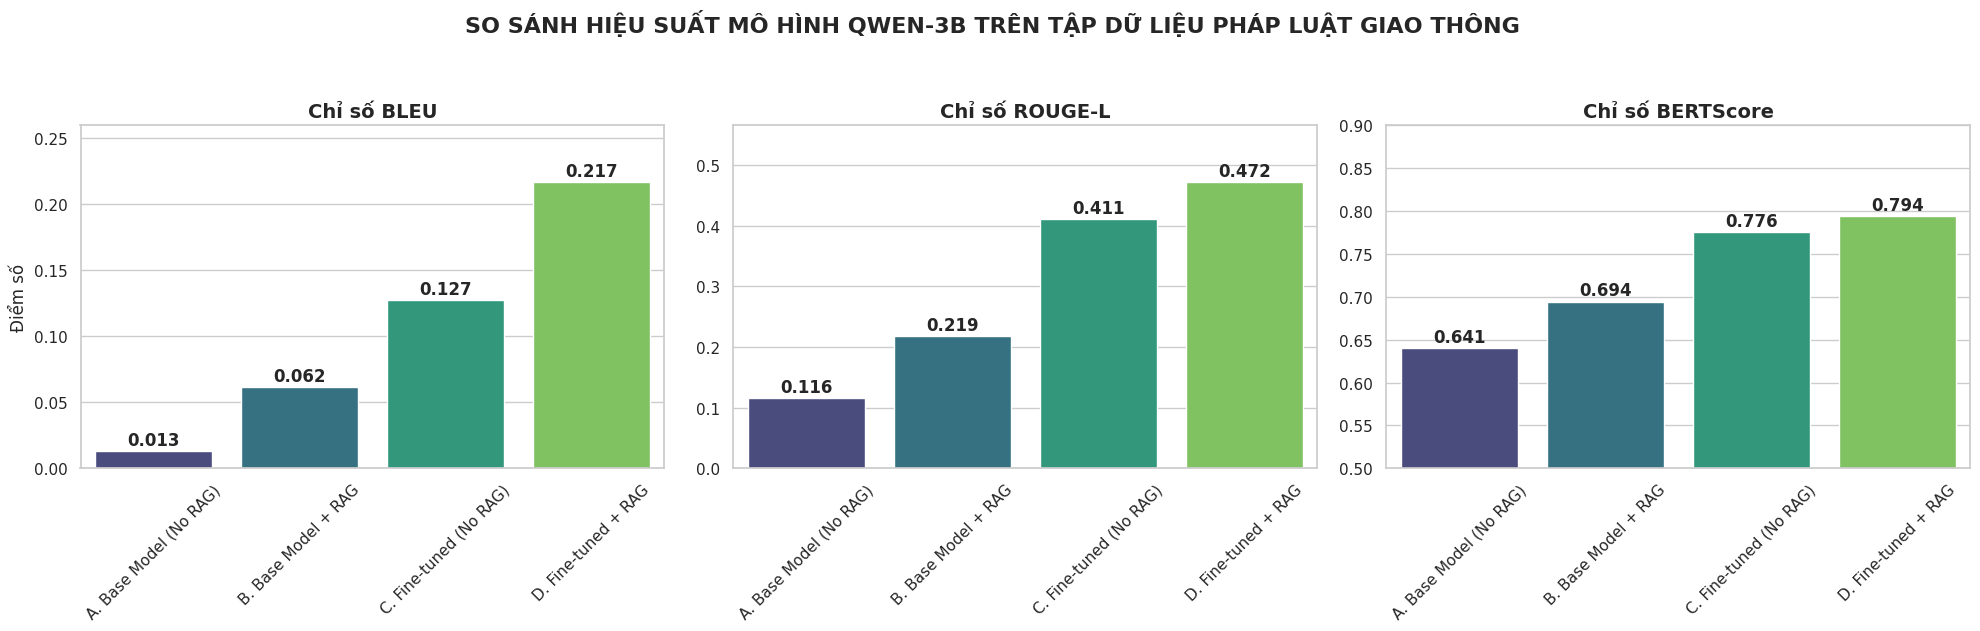

In [11]:
# ==============================================================================
# 5. TRỰC QUAN HÓA KẾT QUẢ ĐÁNH GIÁ
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập phong cách biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Tạo khung vẽ gồm 3 biểu đồ nằm ngang
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('SO SÁNH HIỆU SUẤT MÔ HÌNH QWEN-3B TRÊN TẬP DỮ LIỆU PHÁP LUẬT GIAO THÔNG',
             fontsize=16, fontweight='bold', y=1.05)

metrics = ['BLEU', 'ROUGE-L', 'BERTScore']
colors = sns.color_palette("viridis", len(df['Configuration']))

for i, metric in enumerate(metrics):
    # Vẽ biểu đồ cột cho từng metric
    ax = sns.barplot(data=df, x='Configuration', y=metric, ax=axes[i], palette="viridis")

    axes[i].set_title(f'Chỉ số {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Điểm số' if i == 0 else '')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

    # Giới hạn trục y cho BERTScore để dễ thấy sự chênh lệch
    if metric == 'BERTScore':
        axes[i].set_ylim(0.5, 0.9)
    else:
        axes[i].set_ylim(0, df[metric].max() * 1.2)

    # Gắn label giá trị lên đầu mỗi cột
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontweight='bold')

plt.tight_layout()
plt.show()